In [1]:
import sys
sys.path.append("/Users/27171653/Desktop/PhD/Specular-Highlights/sh_models")

In [ ]:
from pipeline import dhl_generator as dhl_gen
from pipeline import PSDloader as psd_loader
from sh_models import highlight_detector as hd
from sh_models import pconvAE as pc_hr
import matplotlib.pyplot as plt
import torch
from typing import Tuple, Optional
import time
from collections import defaultdict
import torch.nn as nn
import matplotlib.pyplot as plt
from IPython.display import clear_output
from torch.utils.data import DataLoader, Subset

In [3]:
diffuse_images = "/Users/27171653/Desktop/PhD/PSD_Dataset/PSD_Dataset/PSD_Train/PSD_Train_diffuse"
specular_images = "/Users/27171653/Desktop/PhD/PSD_Dataset/PSD_Dataset/PSD_Train/PSD_Train_specular"

dataset, loader = psd_loader.make_psd_dataloader(
    diffuse_dir=diffuse_images,
    specular_dir=specular_images,
    batch_size=4,
    soft_gamma=1.0,
    threshold_method="quantile",
    threshold=0.7,
)

small_dataset = Subset(dataset, [95])  # Just a few samples for quick testing

small_loader = DataLoader(
    small_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

In [4]:
import time
import random
from collections import defaultdict

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from IPython.display import clear_output


def _move_batch_to_device(batch, device):
    out = {}
    for k, v in batch.items():
        out[k] = v.to(device, non_blocking=True) if torch.is_tensor(v) else v
    return out


def _get_loss_fn(loss_name="l1"):
    loss_name = loss_name.lower()
    if loss_name == "bce":
        return nn.BCELoss()
    if loss_name == "l1":
        return nn.L1Loss()
    if loss_name == "mse":
        return nn.MSELoss()
    if loss_name == "smoothl1":
        return nn.SmoothL1Loss()
    raise ValueError("loss_name must be 'bce', 'l1', 'mse', or 'smoothl1'")


@torch.no_grad()
def evaluate_highlight_removal_rgb(model, loader, loss_fn, device):
    model.eval()
    running_loss = 0.0
    n_samples = 0

    for batch in loader:
        batch = _move_batch_to_device(batch, device)

        x = batch["input"].float()       # [B,3,H,W]
        soft_mask = batch["soft_mask"].float()   # [B,1,H,W]
        y_true = batch["target"].float() # [B,3,H,W]

        y_pred = model(x, soft_mask)     # must be [B,3,H,W]
        loss = loss_fn(y_pred, y_true)

        bs = x.shape[0]
        running_loss += loss.item() * bs
        n_samples += bs

    return running_loss / max(n_samples, 1)


@torch.no_grad()
def show_rgb_predictions(model, dataset, device, n_show=3, seed=None):
    if seed is not None:
        random.seed(seed)

    n_show = min(n_show, len(dataset))
    indices = random.sample(range(len(dataset)), n_show)

    model.eval()

    fig, axes = plt.subplots(n_show, 5, figsize=(20, 4 * n_show))
    if n_show == 1:
        axes = axes[None, :]

    for row, idx in enumerate(indices):
        sample = dataset[idx]

        x = sample["input"].unsqueeze(0).to(device).float()          # [1,3,H,W]
        soft_mask = sample["soft_mask"].unsqueeze(0).to(device).float()  # [1,1,H,W]

        y_pred = model(x, soft_mask)[0].detach().cpu().clamp(0, 1)   # [3,H,W]

        inp = sample["input"].permute(1, 2, 0).cpu()                 # [H,W,3]
        target = sample["target"].permute(1, 2, 0).cpu()             # [H,W,3]
        sm = sample["soft_mask"][0].cpu()                            # [H,W]
        pred = y_pred.permute(1, 2, 0)                               # [H,W,3]
        abs_err = (y_pred - sample["target"].cpu()).abs().mean(dim=0)  # [H,W]

        axes[row, 0].imshow(inp)
        axes[row, 0].set_title(f"Input\n{sample['name']}")
        axes[row, 0].axis("off")

        axes[row, 1].imshow(target)
        axes[row, 1].set_title("Ground truth RGB")
        axes[row, 1].axis("off")

        axes[row, 2].imshow(sm, cmap="gray_r", vmin=0, vmax=1)
        axes[row, 2].set_title("Soft mask")
        axes[row, 2].axis("off")

        axes[row, 3].imshow(pred)
        axes[row, 3].set_title("Prediction RGB")
        axes[row, 3].axis("off")

        axes[row, 4].imshow(abs_err, cmap="gray", vmin=0, vmax=1)
        axes[row, 4].set_title("Mean abs error")
        axes[row, 4].axis("off")

    plt.tight_layout()
    plt.show()



In [5]:
def train_highlight_removal_autoencoder(
    train_loader,
    val_loader=None,
    *,
    in_channels=3,
    out_channels=3,
    base_features=64,
    depth=4,
    max_features=512,
    bottleneck_blocks=2,
    use_conv_shift=False,
    lr=1e-3,
    weight_decay=0.0,
    epochs=20,
    device=None,
    loss_name="l1",
    grad_clip=None,
    plot_every=1,
    preview_dataset=None,
    preview_every=0,
    save_best_path=None,
):
    """
    Train RGB highlight removal autoencoder.

    Expected batch format:
        batch["input"]       : [B, 3, H, W]
        batch["target"]      : [B, 3, H, W]
        batch["mask"]        : [B, 1, H, W]   or
        batch["soft_mask"]   : [B, 1, H, W]

    Model interface:
        y_pred = model(x, mask)

    Notes:
        Partial convolution usually expects:
            1 = valid pixel
            0 = invalid / missing pixel
        So if your dataset mask marks highlight pixels as 1,
        you may want to invert it before passing it to the model.
    """
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")

    model = pc_hr.HighlightRemovalAutoencoder(
        in_channels=in_channels,
        out_channels=out_channels,
        base_features=base_features,
        depth=depth,
        max_features=max_features,
        bottleneck_blocks=bottleneck_blocks,
        use_conv_shift=use_conv_shift,
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay,
    )
    loss_fn = _get_loss_fn(loss_name)

    history = defaultdict(list)
    best_score = float("inf")
    start_time = time.time()

    def _extract_mask(batch):
        if "mask" in batch:
            return batch["mask"]
        if "soft_mask" in batch:
            return batch["soft_mask"]
        raise KeyError("Batch must contain either 'mask' or 'soft_mask'.")

    def _save_checkpoint(path, epoch, train_loss, val_loss=None):
        ckpt = {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "train_loss": train_loss,
            "config": {
                "in_channels": in_channels,
                "out_channels": out_channels,
                "base_features": base_features,
                "depth": depth,
                "max_features": max_features,
                "bottleneck_blocks": bottleneck_blocks,
                "use_conv_shift": use_conv_shift,
                "lr": lr,
                "weight_decay": weight_decay,
                "loss_name": loss_name,
            },
        }
        if val_loss is not None:
            ckpt["val_loss"] = val_loss
        torch.save(ckpt, path)

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        n_samples = 0

        for batch in train_loader:
            batch = _move_batch_to_device(batch, device)

            x = batch["input"].float()
            mask = _extract_mask(batch).float()
            y_true = batch["target"].float()

            if x.ndim != 4 or x.shape[1] != 3:
                raise ValueError(f"Expected input shape [B,3,H,W], got {tuple(x.shape)}")
            if y_true.ndim != 4 or y_true.shape[1] != 3:
                raise ValueError(f"Expected target shape [B,3,H,W], got {tuple(y_true.shape)}")
            if mask.ndim != 4 or mask.shape[1] != 1:
                raise ValueError(f"Expected mask shape [B,1,H,W], got {tuple(mask.shape)}")

            optimizer.zero_grad(set_to_none=True)

            y_pred = model(x, mask)

            if y_pred.shape != y_true.shape:
                raise ValueError(
                    f"Prediction and target shapes must match, got "
                    f"{tuple(y_pred.shape)} and {tuple(y_true.shape)}"
                )

            loss = loss_fn(y_pred, y_true)
            loss.backward()

            if grad_clip is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

            optimizer.step()

            bs = x.shape[0]
            running_loss += loss.item() * bs
            n_samples += bs

        train_loss = running_loss / max(n_samples, 1)
        history["train_loss"].append(train_loss)
        history["lr"].append(optimizer.param_groups[0]["lr"])

        val_loss = None
        if val_loader is not None:
            val_loss = evaluate_highlight_removal_rgb(
                model=model,
                loader=val_loader,
                loss_fn=loss_fn,
                device=device,
            )
            history["val_loss"].append(val_loss)

            if val_loss < best_score:
                best_score = val_loss
                if save_best_path is not None:
                    _save_checkpoint(
                        path=save_best_path,
                        epoch=epoch,
                        train_loss=train_loss,
                        val_loss=val_loss,
                    )
        else:
            if train_loss < best_score:
                best_score = train_loss
                if save_best_path is not None:
                    _save_checkpoint(
                        path=save_best_path,
                        epoch=epoch,
                        train_loss=train_loss,
                    )

        if (epoch % plot_every == 0) or (epoch == 1) or (epoch == epochs):
            clear_output(wait=True)

            plt.figure(figsize=(8, 5))
            plt.plot(history["train_loss"], label="Train loss")
            if history.get("val_loss"):
                plt.plot(history["val_loss"], label="Val loss")
            plt.xlabel("Epoch")
            plt.ylabel(loss_name.upper())
            plt.title(f"RGB highlight removal loss, epoch {epoch}/{epochs}")
            plt.grid(True, alpha=0.3)
            plt.legend()
            plt.tight_layout()
            plt.show()

            elapsed_min = (time.time() - start_time) / 60.0
            msg = f"Epoch {epoch}/{epochs} | train: {train_loss:.6f}"
            if val_loss is not None:
                msg += f" | val: {val_loss:.6f}"
            msg += f" | elapsed: {elapsed_min:.1f} min"
            print(msg)

        if (
            preview_dataset is not None
            and preview_every > 0
            and ((epoch % preview_every == 0) or (epoch == epochs))
        ):
            show_rgb_predictions(
                model=model,
                dataset=preview_dataset,
                device=device,
                n_show=3,
            )

    return model, dict(history)

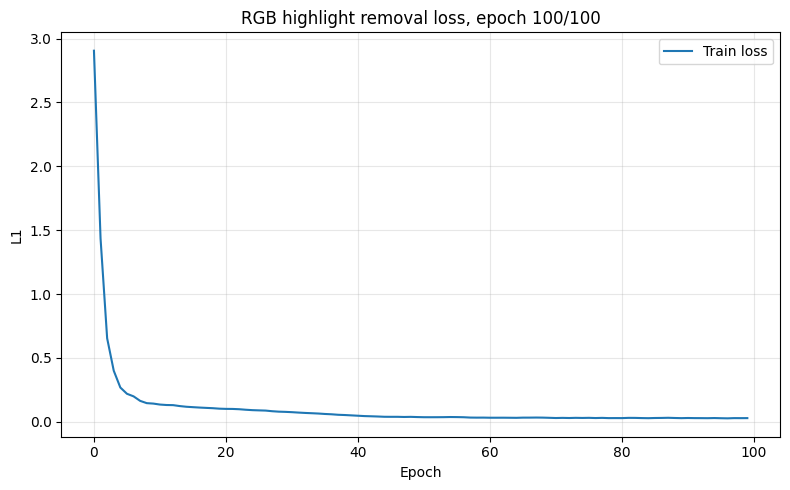

Epoch 100/100 | train: 0.028983 | elapsed: 4.5 min


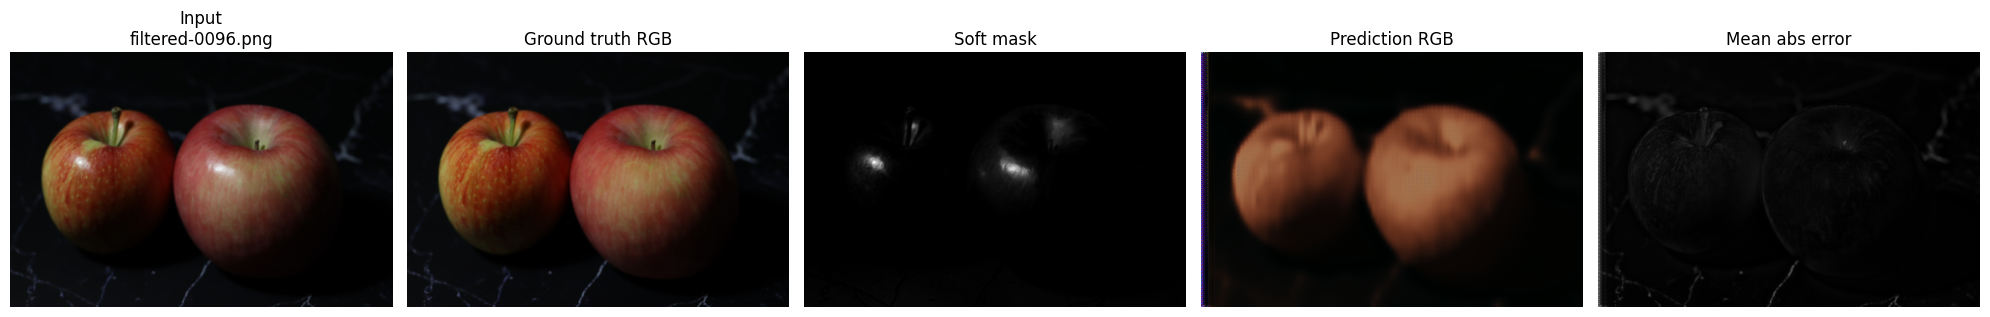

In [6]:
model, history = train_highlight_removal_autoencoder(
    train_loader=small_loader,
    val_loader=None,
    in_channels=3,
    out_channels=3,
    use_conv_shift=False,
    epochs=100,
    device="cpu",
    loss_name="l1",
    preview_dataset=small_dataset,
    preview_every=20,
    save_best_path="best_highlight_removal_rgb.pth",
)

In [7]:

@torch.no_grad()
def evaluate_highlight_detector(model, loader, loss_fn, device, target_key="soft_mask"):
    model.eval()
    running_loss = 0.0
    n_samples = 0

    for batch in loader:
        batch = _move_batch_to_device(batch, device)

        x = batch["input"].float()               # [B,3,H,W]
        y_true = batch[target_key].float()       # [B,1,H,W]

        y_pred = model(x)                        # [B,1,H,W]

        if y_pred.shape != y_true.shape:
            raise ValueError(
                f"Prediction and target shapes must match. "
                f"Got y_pred={tuple(y_pred.shape)} and y_true={tuple(y_true.shape)}"
            )

        loss = loss_fn(y_pred, y_true)

        bs = x.shape[0]
        running_loss += loss.item() * bs
        n_samples += bs

    return running_loss / max(n_samples, 1)


@torch.no_grad()
def show_detector_predictions(model, dataset, device, target_key="soft_mask", n_show=3, seed=None):
    if seed is not None:
        random.seed(seed)

    model.eval()
    n_show = min(n_show, len(dataset))
    indices = random.sample(range(len(dataset)), n_show)

    fig, axes = plt.subplots(n_show, 5, figsize=(18, 4 * n_show))
    if n_show == 1:
        axes = axes[None, :]

    for row, idx in enumerate(indices):
        sample = dataset[idx]

        x = sample["input"].unsqueeze(0).to(device).float()      # [1,3,H,W]
        y_pred = model(x)[0, 0].detach().cpu().clamp(0, 1)       # [H,W]

        inp = sample["input"].permute(1, 2, 0).cpu()
        target = sample["target"].permute(1, 2, 0).cpu()
        soft_mask = sample["soft_mask"][0].cpu()
        gt = sample[target_key][0].cpu()
        err = (y_pred - gt).abs()

        axes[row, 0].imshow(inp)
        axes[row, 0].set_title(f"Input\n{sample['name']}")
        axes[row, 0].axis("off")

        axes[row, 1].imshow(target)
        axes[row, 1].set_title("Diffuse")
        axes[row, 1].axis("off")

        axes[row, 2].imshow(gt, cmap="gray_r", vmin=0, vmax=1)
        axes[row, 2].set_title(f"GT\n{target_key}")
        axes[row, 2].axis("off")

        axes[row, 3].imshow(y_pred, cmap="gray_r", vmin=0, vmax=1)
        axes[row, 3].set_title("Prediction")
        axes[row, 3].axis("off")

        axes[row, 4].imshow(err, cmap="gray", vmin=0, vmax=1)
        axes[row, 4].set_title("Abs error")
        axes[row, 4].axis("off")

    plt.tight_layout()
    plt.show()


def train_highlight_detector(
    train_loader,
    val_loader=None,
    *,
    in_channels=3,
    lr=1e-3,
    weight_decay=0.0,
    epochs=20,
    device=None,
    loss_name="bce",
    target_key="mask",
    grad_clip=None,
    plot_every=1,
    preview_dataset=None,
    preview_every=0,
    save_best_path=None,
):
    """
    Train hd.Detector to predict a highlight map.

    Expected batch keys:
        batch["input"]      -> [B,3,H,W]
        batch[target_key]   -> [B,1,H,W]

    Typical targets:
        target_key="soft_mask"   for continuous map with 0=highlight, 1=non-highlight
        target_key="mask"        for thresholded highlight map
    """
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")

    model = hd.Detector(in_channels=in_channels).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = _get_loss_fn(loss_name)

    history = defaultdict(list)
    best_val = float("inf")
    start_time = time.time()

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        n_samples = 0

        for batch in train_loader:
            batch = _move_batch_to_device(batch, device)

            x = batch["input"].float()
            y_true = batch[target_key].float()

            optimizer.zero_grad(set_to_none=True)

            y_pred = model(x)

            if y_pred.shape != y_true.shape:
                raise ValueError(
                    f"Prediction and target shapes must match. "
                    f"Got y_pred={tuple(y_pred.shape)} and y_true={tuple(y_true.shape)}"
                )

            loss = loss_fn(y_pred, y_true)
            loss.backward()

            if grad_clip is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

            optimizer.step()

            bs = x.shape[0]
            running_loss += loss.item() * bs
            n_samples += bs

        train_loss = running_loss / max(n_samples, 1)
        history["train_loss"].append(train_loss)
        history["lr"].append(optimizer.param_groups[0]["lr"])

        if val_loader is not None:
            val_loss = evaluate_highlight_detector(
                model=model,
                loader=val_loader,
                loss_fn=loss_fn,
                device=device,
                target_key=target_key,
            )
            history["val_loss"].append(val_loss)

            score_for_best = val_loss
        else:
            val_loss = None
            score_for_best = train_loss

        if score_for_best < best_val:
            best_val = score_for_best
            if save_best_path is not None:
                torch.save(
                    {
                        "epoch": epoch,
                        "model_state_dict": model.state_dict(),
                        "optimizer_state_dict": optimizer.state_dict(),
                        "train_loss": train_loss,
                        "val_loss": val_loss,
                        "config": {
                            "in_channels": in_channels,
                            "lr": lr,
                            "weight_decay": weight_decay,
                            "epochs": epochs,
                            "loss_name": loss_name,
                            "target_key": target_key,
                        },
                    },
                    save_best_path,
                )

        if (epoch % plot_every == 0) or (epoch == 1) or (epoch == epochs):
            clear_output(wait=True)

            plt.figure(figsize=(8, 5))
            plt.plot(history["train_loss"], label="Train loss")
            if len(history["val_loss"]) > 0:
                plt.plot(history["val_loss"], label="Val loss")
            plt.xlabel("Epoch")
            plt.ylabel(loss_name.upper())
            plt.title(f"Highlight detector loss, epoch {epoch}/{epochs}")
            plt.grid(True, alpha=0.3)
            plt.legend()
            plt.tight_layout()
            plt.show()

            elapsed = (time.time() - start_time) / 60.0
            msg = f"Epoch {epoch}/{epochs} | train: {train_loss:.6f}"
            if val_loss is not None:
                msg += f" | val: {val_loss:.6f}"
            msg += f" | elapsed: {elapsed:.1f} min"
            print(msg)

        if (
            preview_dataset is not None
            and preview_every > 0
            and ((epoch % preview_every == 0) or (epoch == epochs))
        ):
            show_detector_predictions(
                model=model,
                dataset=preview_dataset,
                device=device,
                target_key=target_key,
                n_show=3,
            )

    return model, dict(history)

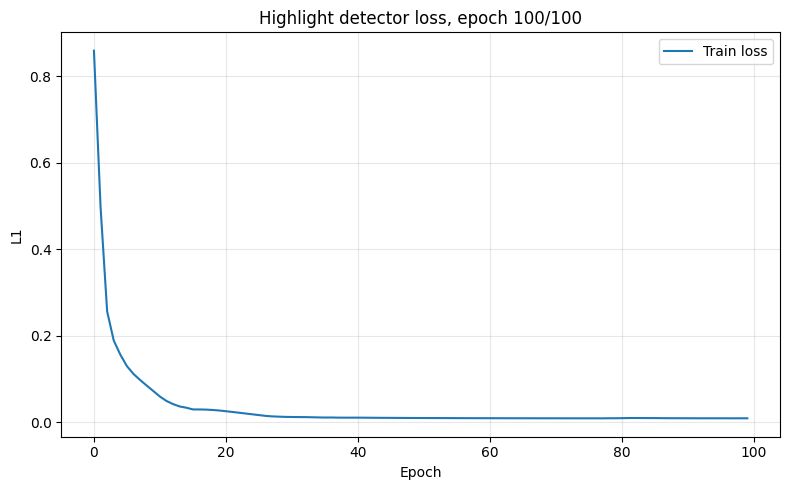

Epoch 100/100 | train: 0.009618 | elapsed: 6.7 min


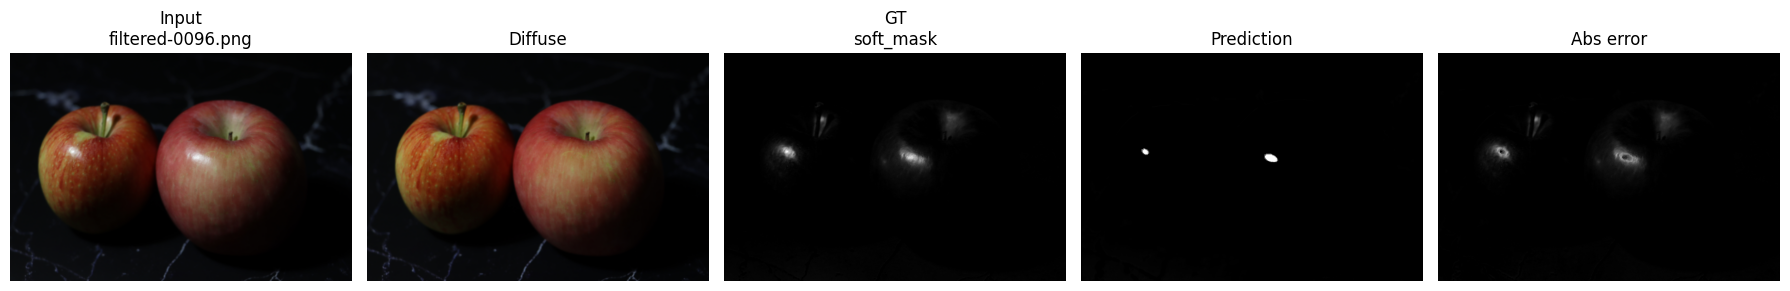

In [10]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model, history = train_highlight_detector(
    train_loader=small_loader,
    val_loader=None,
    in_channels=3,
    lr=1e-3,
    epochs=100,
    device=device,
    loss_name="l1",
    target_key="soft_mask", 
    plot_every=1,
    preview_dataset=small_dataset,
    preview_every=5,
    save_best_path="best_detector_softmask.pth",
)